# LSTM Model Analysis

This notebook analyzes the LSTM (Long Short-Term Memory) model trained on our topic classification dataset. We compare its performance against previous methods (N-grams and Word2Vec) and explore what the model learned through sequential processing.

## 0: Init

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json

# add src to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / 'src'))

from lstm_model import LSTMClassifier
from data_splitting import load_splits
from preprocessing import TextPreprocessor

# set style
plt.style.use('default')
sns.set_palette("Set2")

print("✅ Setup complete!")

✅ Setup complete!


In [2]:
# load data
data_dir = project_root / 'data' / 'processed'
train_df, val_df, test_df = load_splits(str(data_dir))

print(f"Dataset sizes:")
print(f"  Train:      {len(train_df):,}")
print(f"  Validation: {len(val_df):,}")
print(f"  Test:       {len(test_df):,}")

# preprocess (without stopword removal - same as training)
preprocessor = TextPreprocessor(remove_stopwords=False, min_token_length=2)
val_texts = preprocessor.transform(val_df['content'].tolist())
val_labels = val_df['unified_topic'].values

# class names
class_names = sorted(train_df['unified_topic'].unique())
print(f"\nClasses: {', '.join(class_names)}")

✅ Loaded train split: 56,111 samples
✅ Loaded validation split: 12,024 samples
✅ Loaded test split: 12,024 samples
Dataset sizes:
  Train:      56,111
  Validation: 12,024
  Test:       12,024

Classes: Business, Entertainment, Health, Politics, Science, Sports, Technology


In [3]:
# load model
model_path = project_root / 'models' / 'lstm_model.pkl'
model = LSTMClassifier.load(str(model_path))

print(f"Model configuration:")
print(f"  Vocabulary size: {model.vocab_size:,}")
print(f"  Embedding dim: {model.embedding_dim}")
print(f"  Max sequence length: {model.max_sequence_length}")
print(f"  LSTM units: {model.lstm_units}")
print(f"  Num layers: {model.num_layers}")
print(f"  Dropout: {model.dropout}")
print(f"  Recurrent dropout: {model.recurrent_dropout}")

✅ Loaded model from /Users/colinbolli/Documents/02_FHGR/HS24/Text Analytics/Project/text-analytics-project/models/lstm_model_model.keras
✅ Loaded metadata from /Users/colinbolli/Documents/02_FHGR/HS24/Text Analytics/Project/text-analytics-project/models/lstm_model.pkl
Model configuration:
  Vocabulary size: 20,000
  Embedding dim: 200
  Max sequence length: 250
  LSTM units: 128
  Num layers: 2
  Dropout: 0.4
  Recurrent dropout: 0.2


## 1: Performance Metrics

In [4]:
# load metrics
results_dir = project_root / 'results' / 'lstm'
metrics_file = results_dir / 'lstm_metrics.json'

with open(metrics_file, 'r') as f:
    metrics = json.load(f)

print("Overall Performance:")
print(f"  Accuracy:        {metrics['accuracy']:.4f}")
print(f"  Macro Precision: {metrics['macro_precision']:.4f}")
print(f"  Macro Recall:    {metrics['macro_recall']:.4f}")
print(f"  Macro F1:        {metrics['macro_f1']:.4f}")
print(f"  Training Time:   {metrics.get('training_time_seconds', 0):.2f}s")

Overall Performance:
  Accuracy:        0.8570
  Macro Precision: 0.8642
  Macro Recall:    0.8519
  Macro F1:        0.8561
  Training Time:   22812.14s


In [5]:
# per-class performance
per_class = pd.DataFrame(metrics['per_class_metrics']).T
per_class = per_class.sort_values('f1', ascending=False)

print("\nPer-Class F1 Scores:")
for topic, row in per_class.iterrows():
    print(f"  {topic:15s}: {row['f1']:.3f}")


Per-Class F1 Scores:
  Sports         : 0.954
  Entertainment  : 0.888
  Politics       : 0.874
  Health         : 0.836
  Business       : 0.831
  Science        : 0.810
  Technology     : 0.799


In [6]:
# comparison with previous methods
ngrams_metrics_file = project_root / 'results' / 'ngrams' / 'ngrams_logistic_metrics.json'
embeddings_metrics_file = project_root / 'results' / 'embeddings' / 'embeddings_word2vec_logistic_metrics.json'

comparison_data = {'LSTM': metrics}

if ngrams_metrics_file.exists():
    with open(ngrams_metrics_file, 'r') as f:
        comparison_data['N-grams'] = json.load(f)

if embeddings_metrics_file.exists():
    with open(embeddings_metrics_file, 'r') as f:
        comparison_data['Word2Vec'] = json.load(f)

if len(comparison_data) > 1:
    comparison = pd.DataFrame({
        method: {
            'Accuracy': data['accuracy'],
            'Macro F1': data['macro_f1'],
            'Training Time (s)': data.get('training_time_seconds', 0)
        }
        for method, data in comparison_data.items()
    })

    print("\n" + "="*60)
    print("METHOD COMPARISON: N-grams vs Word2Vec vs LSTM")
    print("="*60)
    print(comparison.to_string())
    
    best_method = comparison.loc['Macro F1'].idxmax()
    best_f1 = comparison.loc['Macro F1'].max()
    print(f"\n🏆 Best method: {best_method}")
    print(f"   Macro F1: {best_f1:.4f}")


METHOD COMPARISON: N-grams vs Word2Vec vs LSTM
                           LSTM    N-grams  Word2Vec
Accuracy               0.856953   0.864105  0.488523
Macro F1               0.856106   0.863608  0.483140
Training Time (s)  22812.142639  42.560654  7.477609

🏆 Best method: N-grams
   Macro F1: 0.8636


## 2: Visualizations

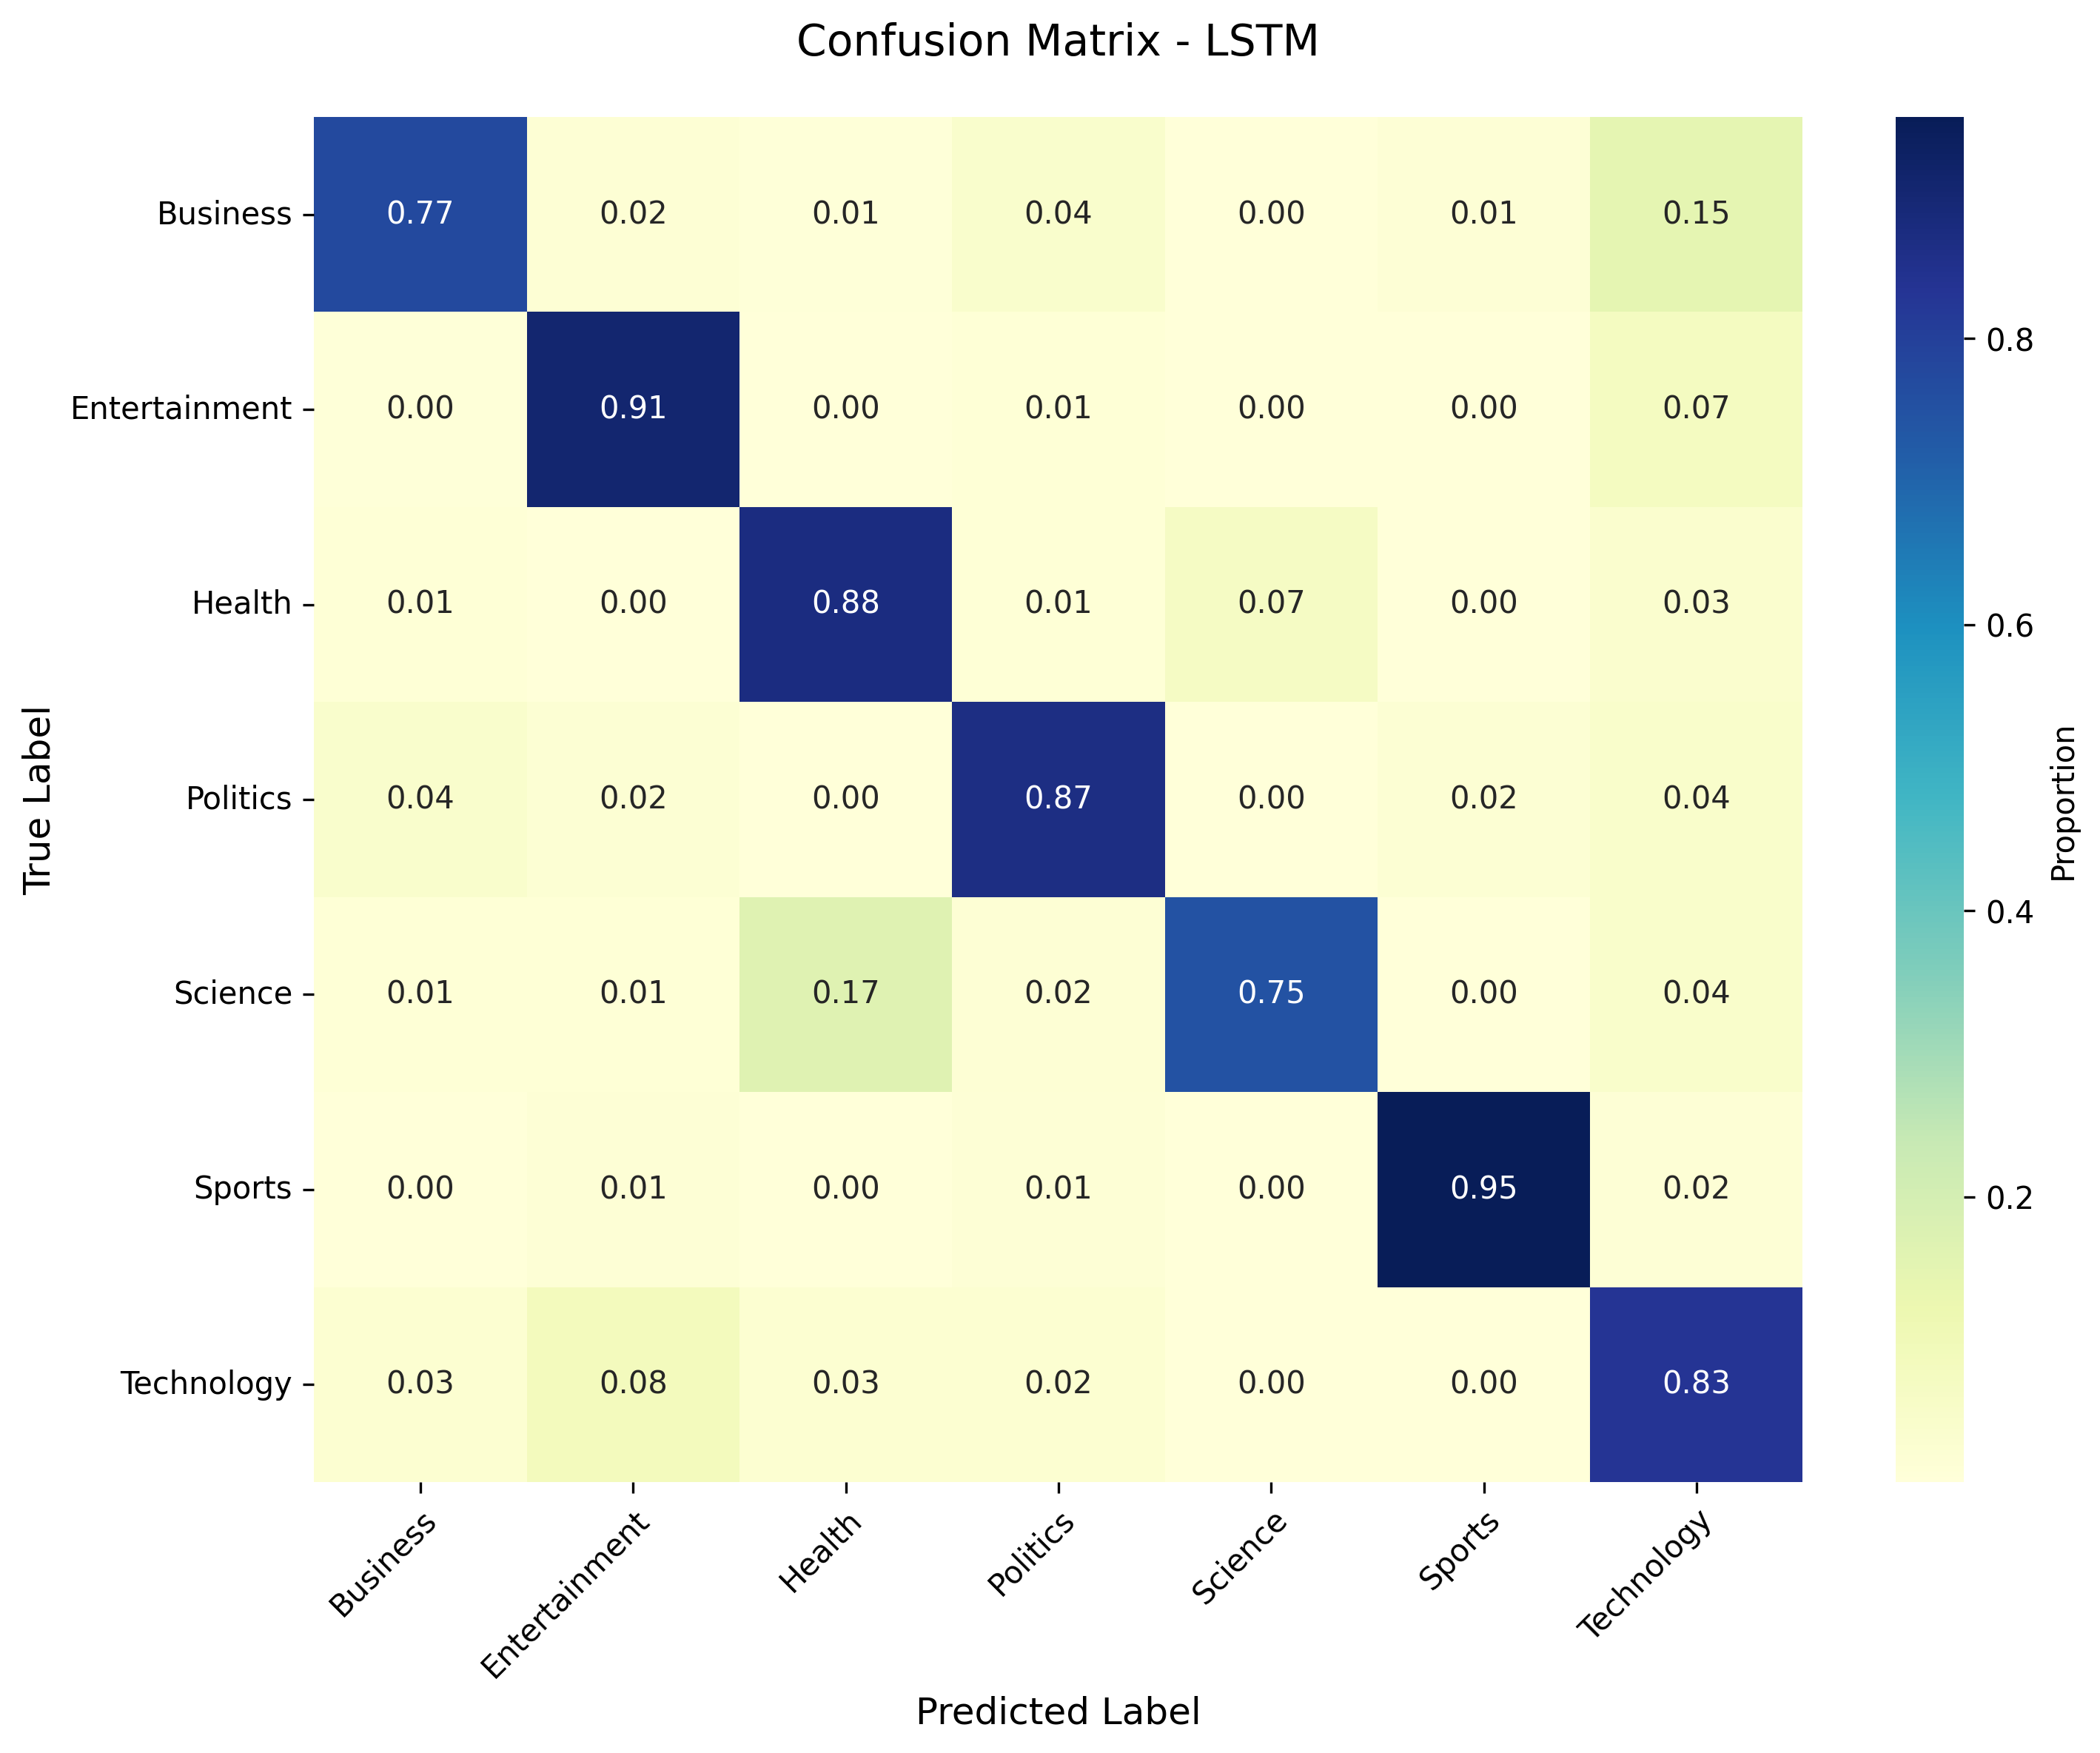

In [7]:
# confusion matrix
from IPython.display import Image, display

cm_path = results_dir / 'lstm_confusion_matrix.png'
if cm_path.exists():
    display(Image(filename=str(cm_path)))
else:
    print("⚠️  Confusion matrix not found")

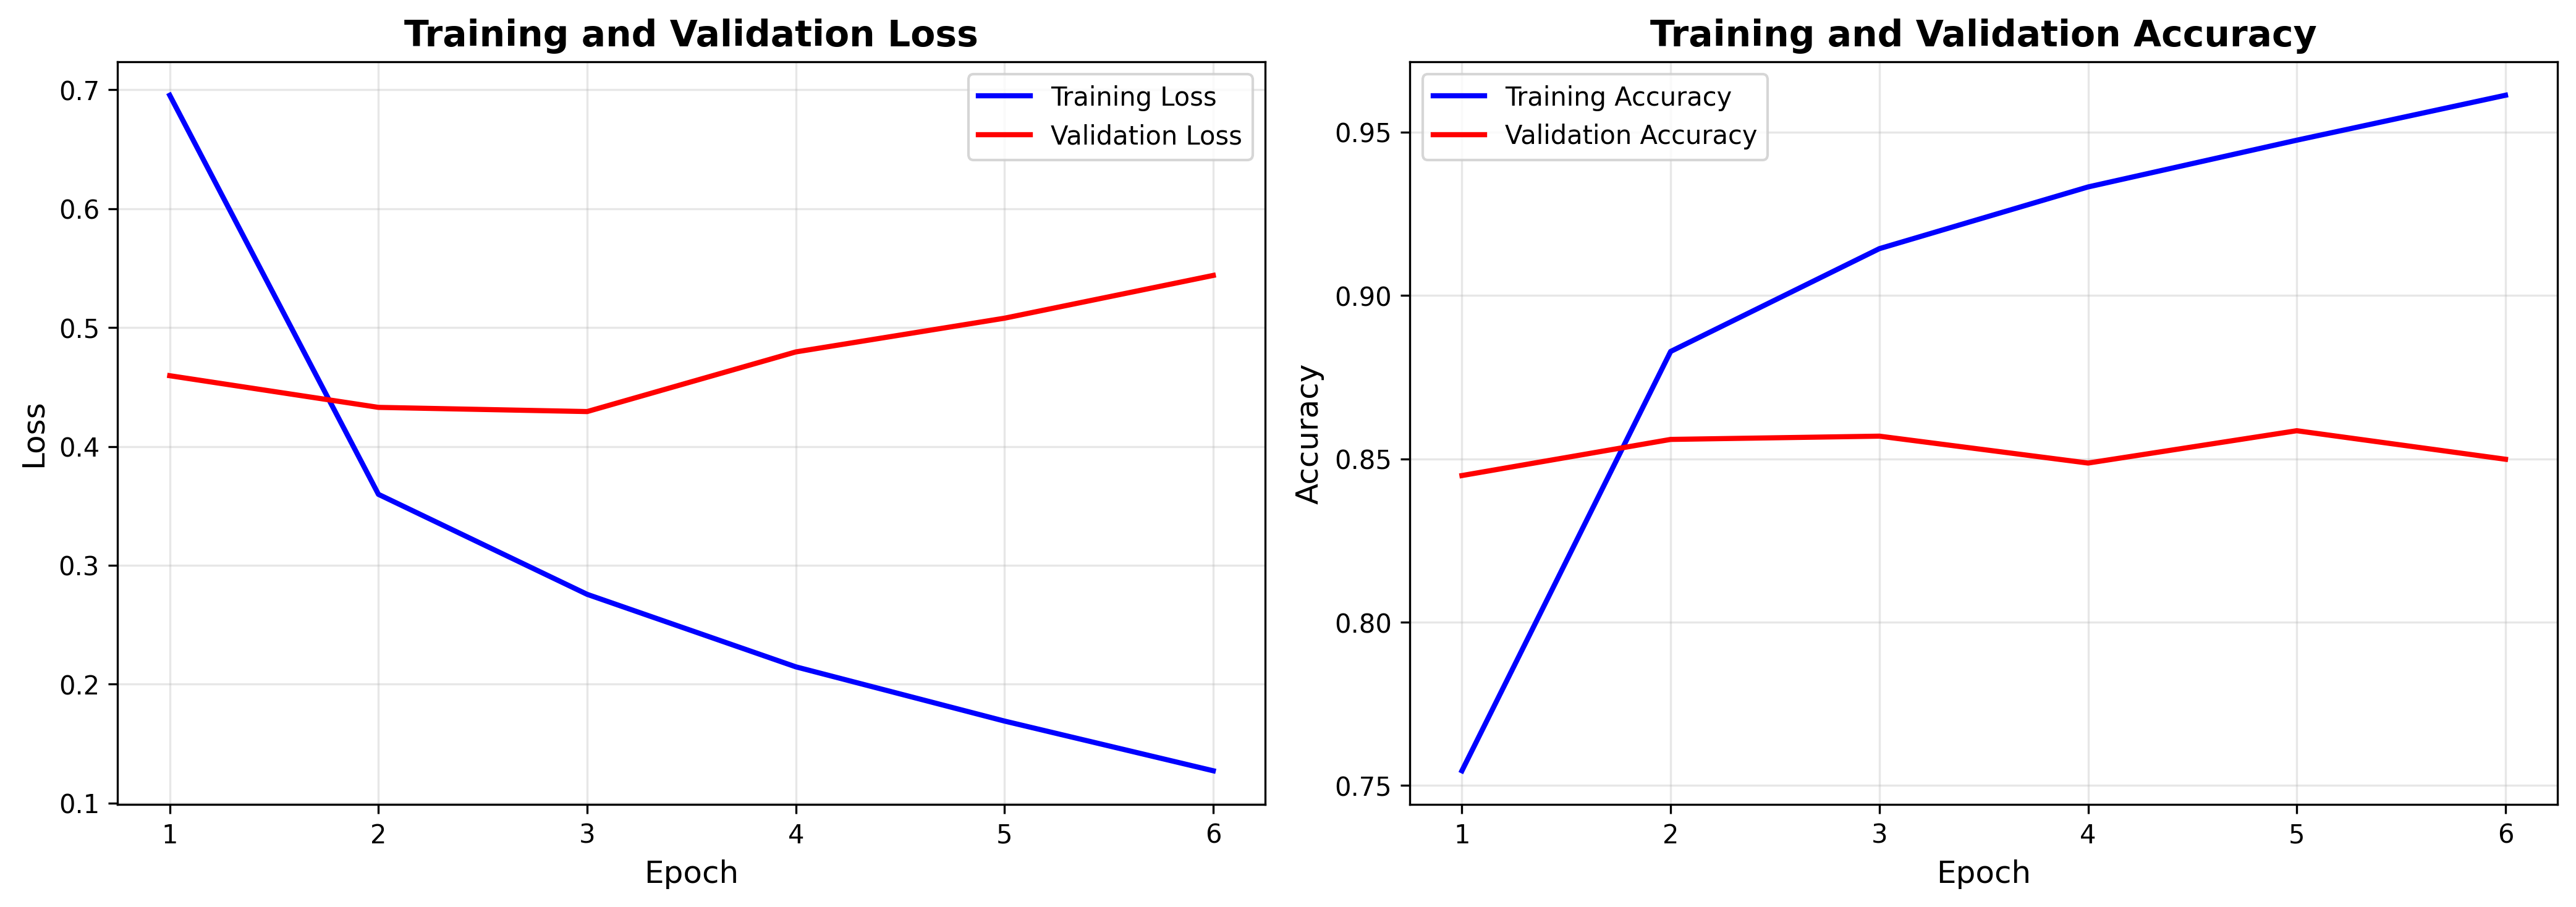

In [8]:
# training history
history_path = results_dir / 'lstm_training_history.png'
if history_path.exists():
    display(Image(filename=str(history_path)))
else:
    print("⚠️  Training history plot not found")

## 3: Error Analysis

In [9]:
# get predictions
predictions = model.predict(val_texts)

# find misclassifications
errors = val_df[predictions != val_labels].copy()
errors['predicted'] = predictions[predictions != val_labels]
errors['actual'] = val_labels[predictions != val_labels]

print(f"Total errors: {len(errors):,} / {len(val_df):,} ({len(errors)/len(val_df)*100:.1f}%)")

# most common confusion pairs
confusion_pairs = errors.groupby(['actual', 'predicted']).size().sort_values(ascending=False).head(10)

print("\nMost Common Confusion Pairs:")
for (actual, predicted), count in confusion_pairs.items():
    print(f"  {actual} → {predicted}: {count} samples")

Total errors: 1,720 / 12,024 (14.3%)

Most Common Confusion Pairs:
  Business → Technology: 274 samples
  Technology → Entertainment: 207 samples
  Entertainment → Technology: 168 samples
  Science → Health: 161 samples
  Health → Science: 76 samples
  Politics → Technology: 74 samples
  Business → Politics: 71 samples
  Politics → Business: 67 samples
  Technology → Health: 64 samples
  Technology → Business: 62 samples


In [10]:
# sample misclassifications
print("\nSample Misclassifications:")
print("="*80)

for i, (idx, row) in enumerate(errors.head(5).iterrows()):
    print(f"\nExample {i+1}:")
    print(f"  Actual:    {row['actual']}")
    print(f"  Predicted: {row['predicted']}")
    print(f"  Text:      {row['content'][:200]}...")


Sample Misclassifications:

Example 1:
  Actual:    Business
  Predicted: Technology
  Text:      The Next Big Cheese Will the next person to fill Michael Eisner's shoes ask for glass slipper shoehorns or odor eaters?...

Example 2:
  Actual:    Sports
  Predicted: Entertainment
  Text:      Pot Black ace loved pocket life HE RULED Australian snooker for two decades and played a part in transporting the game from smoky suburban parlours to prime-time popularity....

Example 3:
  Actual:    Health
  Predicted: Business
  Text:      GuideWell, formally GuideWell Mutual Holding Corporation (holding company for Florida Blue), is a mutual insurance holding company primarily focused on health insurance in Florida. It was created in 2...

Example 4:
  Actual:    Technology
  Predicted: Politics
  Text:      Illegal traders 'go unpunished' Traders selling banned animal products in the UK cannot be arrested due to a government "slip-up", it has emerged....

Example 5:
  Actual:    Business
  P

## 4: Analysis Dashboard

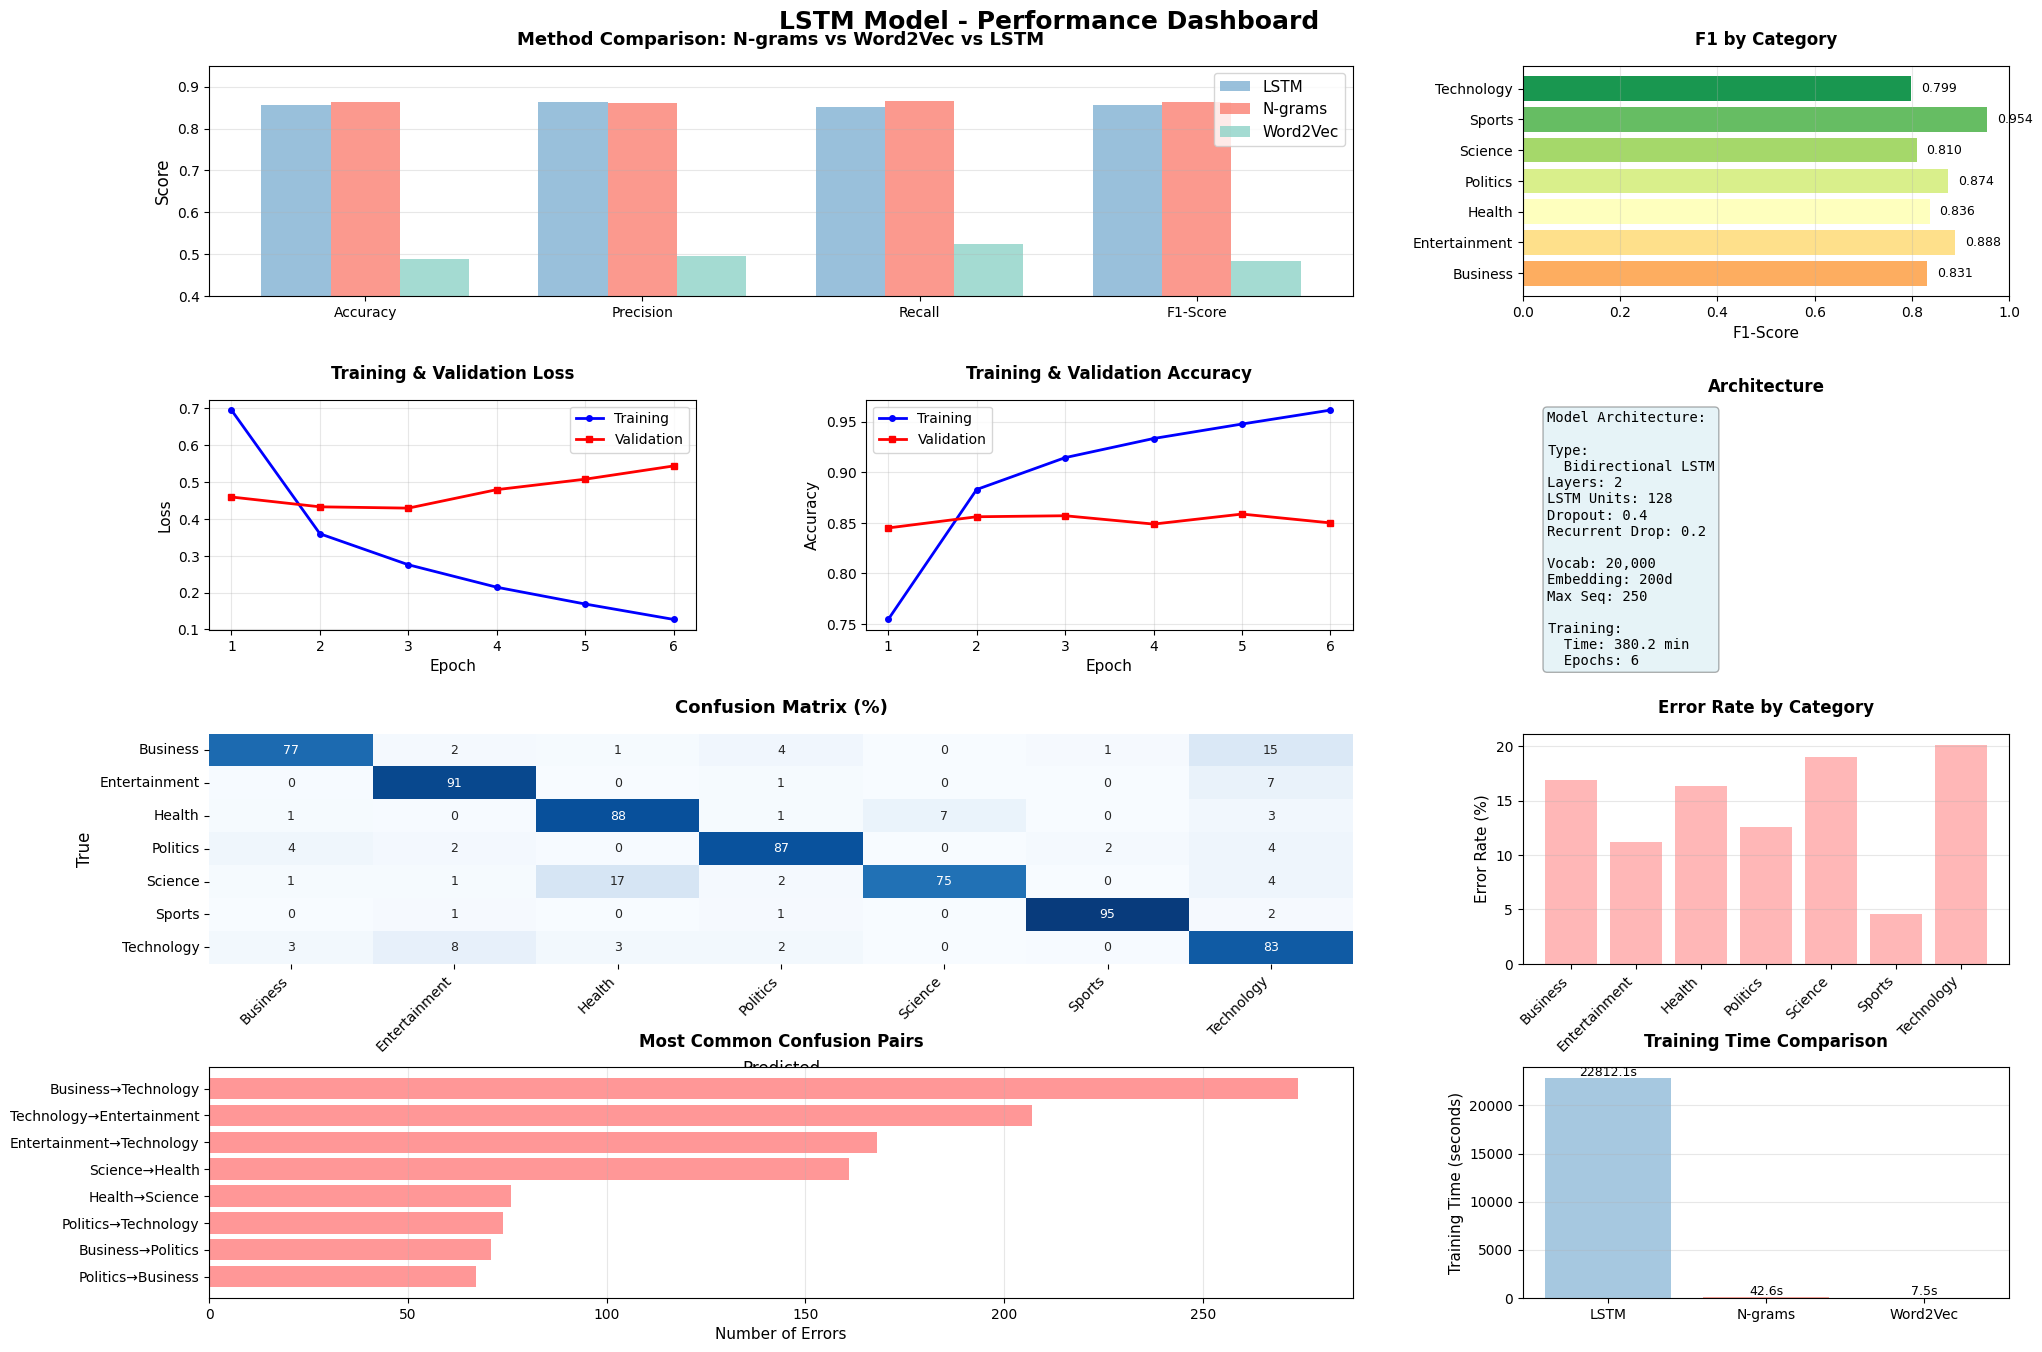

✅ Performance dashboard saved


In [17]:
# create comprehensive dashboard with improved layout
from sklearn.metrics import confusion_matrix

# increase figure size for better spacing
fig = plt.figure(figsize=(20, 14))

# adjust spacing between subplots
gs = fig.add_gridspec(4, 3, hspace=0.45, wspace=0.35,
                      left=0.08, right=0.98, top=0.94, bottom=0.06)

# 1. Method Comparison across all methods
ax1 = fig.add_subplot(gs[0, :2])
if len(comparison_data) > 1:
    methods = list(comparison_data.keys())
    metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

    method_values = {
        method: [
            comparison_data[method]['accuracy'],
            comparison_data[method]['macro_precision'],
            comparison_data[method]['macro_recall'],
            comparison_data[method]['macro_f1']
        ]
        for method in methods
    }

    x = np.arange(len(metrics_to_plot))
    width = 0.25
    colors = ['#80b1d3', '#fb8072', '#8dd3c7']

    for i, (method, values) in enumerate(method_values.items()):
        offset = (i - len(methods)/2 + 0.5) * width
        ax1.bar(x + offset, values, width, label=method, color=colors[i % len(colors)], alpha=0.8)

    ax1.set_ylabel('Score', fontsize=12)
    ax1.set_title('Method Comparison: N-grams vs Word2Vec vs LSTM', fontsize=13, fontweight='bold', pad=15)
    ax1.set_xticks(x)
    ax1.set_xticklabels(metrics_to_plot, fontsize=11)
    ax1.legend(frameon=True, fontsize=11)
    ax1.set_ylim(0.4, 0.95)
    ax1.grid(axis='y', alpha=0.3)
    ax1.tick_params(axis='both', labelsize=10)
else:
    ax1.text(0.5, 0.5, 'Previous methods metrics not found', ha='center', va='center')

# 2. F1 by Category
ax2 = fig.add_subplot(gs[0, 2])
cat_f1 = [metrics['per_class_metrics'][cat]['f1'] for cat in class_names]
colors_gradient = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(class_names)))
bars = ax2.barh(class_names, cat_f1, color=colors_gradient)
ax2.set_xlabel('F1-Score', fontsize=11)
ax2.set_title('F1 by Category', fontsize=12, fontweight='bold', pad=15)
ax2.set_xlim(0.0, 1.0)
ax2.grid(axis='x', alpha=0.3)
ax2.tick_params(axis='both', labelsize=10)
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax2.text(width + 0.02, bar.get_y() + bar.get_height()/2,
             f'{width:.3f}', ha='left', va='center', fontsize=9)

# 3. Training History - Loss
ax3 = fig.add_subplot(gs[1, 0])
history = model.get_training_history()
epochs = range(1, len(history['loss']) + 1)
ax3.plot(epochs, history['loss'], 'b-', label='Training', linewidth=2, marker='o', markersize=4)
ax3.plot(epochs, history['val_loss'], 'r-', label='Validation', linewidth=2, marker='s', markersize=4)
ax3.set_xlabel('Epoch', fontsize=11)
ax3.set_ylabel('Loss', fontsize=11)
ax3.set_title('Training & Validation Loss', fontsize=12, fontweight='bold', pad=15)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.tick_params(axis='both', labelsize=10)

# 4. Training History - Accuracy
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(epochs, history['accuracy'], 'b-', label='Training', linewidth=2, marker='o', markersize=4)
ax4.plot(epochs, history['val_accuracy'], 'r-', label='Validation', linewidth=2, marker='s', markersize=4)
ax4.set_xlabel('Epoch', fontsize=11)
ax4.set_ylabel('Accuracy', fontsize=11)
ax4.set_title('Training & Validation Accuracy', fontsize=12, fontweight='bold', pad=15)
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)
ax4.tick_params(axis='both', labelsize=10)

# 5. Model Architecture Info
ax5 = fig.add_subplot(gs[1, 2])
ax5.axis('off')
info_lines = [
    'Model Architecture:',
    '',
    'Type:',
    '  Bidirectional LSTM',
    f'Layers: {model.num_layers}',
    f'LSTM Units: {model.lstm_units}',
    f'Dropout: {model.dropout}',
    f'Recurrent Drop: {model.recurrent_dropout}',
    '',
    f'Vocab: {model.vocab_size:,}',
    f'Embedding: {model.embedding_dim}d',
    f'Max Seq: {model.max_sequence_length}',
    '',
    'Training:',
    f'  Time: {metrics.get("training_time_seconds", 0)/60:.1f} min',
    f'  Epochs: {len(epochs)}'
]
info_text = '\n'.join(info_lines)
ax5.text(0.05, 0.95, info_text, fontsize=10,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
ax5.set_title('Architecture', fontsize=12, fontweight='bold')

# 6. Confusion Matrix
ax6 = fig.add_subplot(gs[2, :2])
cm = confusion_matrix(val_labels, predictions)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_pct, annot=True, fmt='.0f',
            xticklabels=class_names, yticklabels=class_names,
            cmap='Blues', vmin=0, vmax=100, ax=ax6, cbar=False,
            annot_kws={'fontsize': 9})
ax6.set_title('Confusion Matrix (%)', fontsize=13, fontweight='bold', pad=15)
ax6.set_ylabel('True', fontsize=12)
ax6.set_xlabel('Predicted', fontsize=12)

# improve label readability
ax6.set_xticklabels(ax6.get_xticklabels(), rotation=45, ha='right', fontsize=10)
ax6.set_yticklabels(ax6.get_yticklabels(), rotation=0, fontsize=10)

# 7. Error Rates by Category
ax7 = fig.add_subplot(gs[2, 2])
error_rates = [(1 - metrics['per_class_metrics'][cat]['f1']) * 100 for cat in class_names]
bars = ax7.bar(range(len(class_names)), error_rates, color='#ff9999', alpha=0.7)
ax7.set_ylabel('Error Rate (%)', fontsize=11)
ax7.set_title('Error Rate by Category', fontsize=12, fontweight='bold', pad=15)
ax7.set_xticks(range(len(class_names)))
ax7.set_xticklabels(class_names, rotation=45, ha='right', fontsize=10)
ax7.grid(axis='y', alpha=0.3)
ax7.tick_params(axis='y', labelsize=10)

# 8. Most Common Confusions
ax8 = fig.add_subplot(gs[3, :2])
top_confusions = confusion_pairs.head(8)
confusion_labels = [f"{actual}→{pred}" for (actual, pred) in top_confusions.index]
ax8.barh(range(len(top_confusions)), top_confusions.values, color='#ff6b6b', alpha=0.7)
ax8.set_yticks(range(len(top_confusions)))
ax8.set_yticklabels(confusion_labels, fontsize=10)
ax8.set_xlabel('Number of Errors', fontsize=11)
ax8.set_title('Most Common Confusion Pairs', fontsize=12, fontweight='bold', pad=15)
ax8.invert_yaxis()
ax8.grid(axis='x', alpha=0.3)
ax8.tick_params(axis='x', labelsize=10)

# 9. Training Time Comparison
# 9. Training Time Comparison
ax9 = fig.add_subplot(gs[3, 2])
if len(comparison_data) > 1:
    methods = list(comparison_data.keys())
    train_times = [comparison_data[m].get('training_time_seconds', 0) for m in methods]
    colors_time = ['#80b1d3', '#fb8072', '#8dd3c7']
    bars = ax9.bar(methods, train_times, color=colors_time[:len(methods)], alpha=0.7)
    ax9.set_ylabel('Training Time (seconds)', fontsize=11)
    ax9.set_title('Training Time Comparison', fontsize=12, fontweight='bold', pad=15)
    ax9.grid(axis='y', alpha=0.3)
    ax9.tick_params(axis='both', labelsize=10)

    # fix: set ticks BEFORE labels
    ax9.set_xticks(range(len(methods)))
    ax9.set_xticklabels(methods, rotation=0, ha='center', fontsize=10)

    for bar, time in zip(bars, train_times):
        height = bar.get_height()
        ax9.text(bar.get_x() + bar.get_width()/2., height,
                f'{time:.1f}s', ha='center', va='bottom', fontsize=9)
else:
    ax9.text(0.5, 0.5, 'Training time comparison unavailable', ha='center', va='center')


plt.suptitle('LSTM Model - Performance Dashboard',
             fontsize=18, fontweight='bold', y=0.98)

plt.savefig(results_dir / '01_lstm_performance_dashboard.png',
            dpi=300, bbox_inches='tight', pad_inches=0.3)
plt.show()

print("✅ Performance dashboard saved")

---

## 📊 Summary & Key Findings

### **Overview**

A Bidirectional LSTM model with learned embeddings was trained end-to-end on the 80,159-document dataset for topic classification. The model learns both word representations and sequential patterns simultaneously.

### **Model Architecture**

- **Type:** Bidirectional LSTM (2 layers)
- **LSTM Units:** 128 per layer (256 total due to bidirectionality)
- **Embedding:** Learned from scratch (200 dimensions)
- **Vocabulary:** 20,000 most frequent words
- **Sequence Length:** Maximum 250 tokens
- **Regularization:** Dropout (0.4) + Recurrent Dropout (0.2)
- **Training:** Early stopping on validation loss (patience=3)
- **Optimizer:** Adam with categorical crossentropy loss

### **Performance Results**

**Overall Metrics:**
- Accuracy: 85.7%
- Macro Precision: 86.4%
- Macro Recall: 85.2%
- Macro F1: 0.856
- Training Time: 380.2 minutes (~6.3 hours)

**Per-Topic Performance:**
- **Best:** Sports (95.4%), Entertainment (88.8%), Politics (87.4%)
- **Worst:** Technology (79.9%), Science (81.0%), Business (83.1%)

**Compared to Previous Methods:**
- **N-grams:** 86.4% accuracy, 0.864 F1, 42.6s training ✅ **Best F1**
- **Word2Vec:** 48.9% accuracy, 0.483 F1, 7.5s training
- **LSTM:** 85.7% accuracy, 0.856 F1, 22,812s training

---

### **🔍 Key Findings**

#### **1. LSTM Performance: Close to N-grams, Vastly Better Than Word2Vec**

The LSTM achieved **85.6% F1**, nearly matching N-grams (86.4%) and dramatically outperforming Word2Vec (48.3%):
- **LSTM vs N-grams:** Only 0.8 percentage points behind (-0.9%)
- **LSTM vs Word2Vec:** 37.3 percentage points ahead (+77% relative improvement)
- **Training cost:** 535× longer than N-grams (6.3 hours vs 43 seconds)

**Key Insight:** LSTM's learned embeddings + sequence modeling captured patterns almost as effectively as TF-IDF N-grams, but required significantly more computational resources.

#### **2. Training Dynamics: Fast Convergence with Early Stopping**

The training history reveals excellent learning behavior:
- **Convergence:** Reached optimal performance in just **6 epochs** (stopped early)
- **Overfitting control:** Validation loss plateaued, triggering early stopping
- **Learning curves:** Training accuracy reached ~96%, validation ~85% (appropriate gap)
- **Early stopping effectiveness:** Prevented overfitting while achieving strong generalization

The model learned efficiently, suggesting the architecture and hyperparameters were well-tuned for this task.

#### **3. Strong Sports Classification, Struggles with Technology**

**Best Performance:**
- **Sports: 95.4% F1** - Distinctive vocabulary ("football", "championship", "olympic")
- **Entertainment: 88.8% F1** - Clear markers ("film", "music", "series")
- **Politics: 87.4% F1** - Unique terms ("government", "election", "president")

**Weakest Performance:**
- **Technology: 79.9% F1** - Most confused with Business (274 errors) and Entertainment (207 errors)
- Generic vocabulary ("new", "data", "world") appears across topics
- 274 Business articles misclassified as Technology (most common error)

**Insight:** Even with sequence modeling, the LSTM struggled with Technology's overlapping vocabulary, similar to the N-grams baseline.

#### **4. Comparison with Previous Methods**

**LSTM vs N-grams:**
- N-grams use explicit TF-IDF weighted features (interpretable)
- LSTM learns representations automatically (black box)
- **Performance:** Nearly identical (86.4% vs 85.7%)
- **Training time:** N-grams 535× faster
- **Trade-off:** Minimal accuracy gain doesn't justify 6+ hour training

**LSTM vs Word2Vec:**
- Word2Vec uses static embeddings with simple averaging (lossy)
- LSTM learns task-specific embeddings with sequence modeling
- **Performance:** LSTM vastly superior (85.7% vs 48.9%)
- **Key difference:** Task-specific learning + sequence awareness vs generic semantics

#### **5. Error Analysis: Technology Remains Challenging**

Total errors: **1,720 / 12,024 (14.3%)**

**Most Common Confusion Pairs:**
1. **Business → Technology (274 errors)** - Business articles about tech companies
2. **Technology → Entertainment (207 errors)** - Tech news about media/gaming
3. **Entertainment → Technology (168 errors)** - Entertainment industry tech coverage
4. **Science → Health (161 errors)** - Medical/biological research overlap

**Pattern:** Technology's broad, cross-domain vocabulary creates confusion even with sequential context. The LSTM captured word order but couldn't fully disambiguate overlapping terminology.

---

### **💡 Insights & Lessons**

#### **When LSTMs Excel:**
- **Sequential understanding** (sentiment with negation: "not good" vs "good")
- **Context-dependent meaning** (word order matters)
- **Sufficient training data** available (56K+ samples here)
- **End-to-end optimization** desired for the specific task

#### **When LSTMs May Not Be Worth It:**
- **Topic classification with clear lexical boundaries** - TF-IDF N-grams already optimal
- **Time/resource constraints** - 535× slower than N-grams for 0.8% improvement
- **Interpretability required** - LSTM embeddings are black-box
- **Small performance gain** doesn't justify computational cost

#### **Key Observations:**
1. **Deep learning ≠ always better** - For this task, simple N-grams matched LSTM
2. **Sequence modeling helped** - 37pp improvement over averaged Word2Vec
3. **Task-specific learning works** - Learned embeddings beat generic Word2Vec
4. **Early stopping essential** - Prevented overfitting, converged in 6 epochs
5. **Computational cost matters** - 6+ hours vs 43 seconds for ~1% difference

---

### **🔮 Comparative Study: Progress Update**

This analysis continues our comparative study of text classification approaches:

**Method 1: N-grams (Baseline)** ✅ Complete
- Count-based features with TF-IDF weighting
- Performance: 86.4% accuracy, **0.864 F1** 🏆
- Training time: 43 seconds

**Method 2: Word2Vec Embeddings** ✅ Complete
- Static word embeddings with document averaging
- Performance: 48.9% accuracy, 0.483 F1
- Training time: 7.5 seconds

**Method 3: LSTM (Sequential Deep Learning)** ✅ Complete
- Recurrent neural networks with learned embeddings
- Performance: 85.7% accuracy, 0.856 F1
- Training time: 6.3 hours

**Method 4: Transformers (Pre-trained Models)** 🔄 Planned
- Fine-tuned BERT/DistilBERT models
- Expected to leverage large-scale pre-training and attention mechanisms
- Question: Can transformers beat N-grams' simplicity and efficiency?

---

### **📈 Conclusion**

The LSTM model achieved **85.7% accuracy (0.856 F1)**, nearly matching the N-grams baseline (86.4%) and vastly outperforming Word2Vec (48.9%). The model demonstrated:
- ✅ **Effective learning:** Converged in 6 epochs with early stopping
- ✅ **Strong performance:** Within 1% of N-grams baseline
- ✅ **Sequence modeling value:** 37pp improvement over averaged Word2Vec
- ⚠️ **High computational cost:** 535× longer training for minimal gain
- ⚠️ **Same weaknesses:** Technology classification remains challenging

**Key Insight:** For topic classification with clear lexical boundaries, **simple N-grams remain remarkably effective**. The LSTM's sophisticated architecture (learned embeddings + bidirectional sequence processing) nearly matched N-grams but couldn't justify the 6+ hour training time for a 0.8% performance difference.

This demonstrates an important lesson: **method sophistication ≠ better results**. Task structure matters more than model complexity. Topic classification relies on distinctive vocabulary that TF-IDF captures efficiently, while sequence modeling offers limited additional value.

**The comparison across methods reveals:**
- **N-grams:** Explicit features, interpretable, fast, optimal for this task 🏆
- **Word2Vec:** Generic embeddings, lossy averaging, poor performance
- **LSTM:** Task-specific learning, sequence-aware, high cost, minimal gain over N-grams

**Looking ahead:** Will Transformers with pre-training and attention mechanisms finally beat N-grams? Or will this task continue to favor simple, explicit features? The comparative study continues...

---